In [63]:
import re
import numpy as np
import pandas as pd
from gensim.models import Word2Vec, Phrases
from gensim.models.phrases import Phraser
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from adjustText import adjust_text
import matplotlib.pyplot as plt

In [77]:
df = pd.read_csv('..//final_df//cleaned_final_df.csv')
df.head()

,title,outlet,date,authors,body,word_count,ai_related,matched_keywords_title,matched_keywords_body,matched_keywords_all,...,date_parsed,year,topic,probability,topic_norm,topic_label_nl,topic_meta_nl,topic_label,topic_meta,ai_words
0,Chatbot Emma glimlacht na een compliment Chatb...,Parool,2015-10-23,BART VAN ZOELEN,"'Dag Denise, hoe oud ben jij?"" vragen we Denis...",238,yes,['chatbot'],['chatbots'],"['chatbot', 'chatbots']",...,2015-10-23,2015,8,0.153558,8,facebook en algoritmen,SOCIALE MEDIA,facebook and algorithms,SOCIAL MEDIA,[]
1,Vera en Roos hebben het druk Vera en Roos hebb...,Parool,2015-10-23,BART VAN ZOELEN,Klantenservice: Virtuele medewerkers kunnen st...,249,yes,[],"['chatbot', 'chatbots']","['chatbot', 'chatbots']",...,2015-10-23,2015,8,0.212454,8,facebook en algoritmen,SOCIALE MEDIA,facebook and algorithms,SOCIAL MEDIA,[]
2,Leer van big data-incidenten Leer van big data...,Parool,2015-01-03,Unknown Authors,Keerpunt: De doorbraak van big data \nBracht 2...,303,yes,[],['slimme algoritmes'],['slimme algoritmes'],...,2015-01-03,2015,12,0.128177,12,bitcoin,BEDRIJF & FINANCIËN,bitcoin,BUSINESS & FINANCE,[]
3,Brieven Brieven,Parool,2015-09-03,Unknown Authors,Geen vrije keuze \nVrijdag had Het Parool een ...,310,yes,[],['algoritme'],['algoritme'],...,2015-09-03,2015,14,0.373948,14,onderwijs,ONDERWIJS,eductation,EDUCATION,[]
4,Stad van stenen en pixels Stad van stenen en p...,Parool,2015-05-19,TRACY METZ,"De talkshow Stadsleven, deze maand tegelijk me...",317,yes,[],['algoritme'],['algoritme'],...,2015-05-19,2015,8,1.000000,8,facebook en algoritmen,SOCIALE MEDIA,facebook and algorithms,SOCIAL MEDIA,[]


In [65]:
df['processed'].iloc[0]

'denise energiemaatschappij vrouw leeftijd uitzondering procent medewerker Maud fleur inshared roos beantwoording vertrouwen systeem directeur bedrijf medewerker internet bedrijf grap laptop Dokman robo yamuda medewerker publiek webwinkel vermogensbeheerder moeder antwoord chatbot verzoek mop glimlach tevoorschijn compliment dokman trut kost foto medewerker doel antwoord gebruik klanttevredenheid geld beantwoording'

In [ ]:
# -----------------------------
# 2) Tokenize
# -----------------------------
from spacy.lang.nl.stop_words import STOP_WORDS as NL_STOPWORDS

def tokenize(text: str):
    text = str(text).lower()
    return [tok for tok in re.split(r"[^a-zà-ÿ]+", text)
            if len(tok) > 2 and tok not in NL_STOPWORDS]

# # Filter docs
# mask = df["body"].astype(str).str.contains(keyword_regex, na=False)
# df_ai = df.loc[mask].copy()

# print(f"Docs after AI filter: {len(df_ai)}")
# print(df_ai["year"].value_counts().sort_index())

all_docs_tokens = df["body"].astype(str).map(tokenize).tolist()
# years = df_ai["year"].astype(int).tolist()


In [102]:
center_phrase_raw = "kunstmatige intelligentie"
center_word = center_phrase_raw.replace(" ", "_")   # phrase-form token

periods = [(2015, 2018), (2019, 2022), (2023, 2025)]
topn = 40
n_clusters = 4
min_count_period = 2
phrase_threshold = 8
phrase_min_count = 5

In [87]:

# -----------------------------
# 3) Phrase detection ONCE
# -----------------------------
bigram = Phrases(all_docs_tokens, min_count=phrase_min_count, threshold=phrase_threshold, delimiter="_")
bigram_phraser = Phraser(bigram)
trigram = Phrases(bigram_phraser[all_docs_tokens], min_count=phrase_min_count, threshold=phrase_threshold, delimiter="_")
trigram_phraser = Phraser(trigram)

def apply_phrasing(doc_tokens):
    return trigram_phraser[bigram_phraser[doc_tokens]]

# Diagnostics: frequency of raw vs underscored
raw_count_total = sum(" ".join(toks).count(center_phrase_raw) for toks in all_docs_tokens)
phrased_corpus = [apply_phrasing(toks) for toks in all_docs_tokens]
underscored_total = sum(doc.count(center_word) for doc in phrased_corpus)
print(f"Raw '{center_phrase_raw}' occurrences (pre-phrase): {raw_count_total}")
print(f"Underscored '{center_word}' occurrences (post-phrase): {underscored_total}")


Raw 'artificiële intelligentie' occurrences (pre-phrase): 847
Underscored 'artificiële_intelligentie' occurrences (post-phrase): 692


In [ ]:
# -----------------------------
# 4) Helper to slice per period
# -----------------------------
def docs_in_period(token_lists, yrs, start, end):
    return [doc for doc, y in zip(token_lists, yrs) if start <= y <= end]

def count_in_period(token_lists, yrs, token, start, end):
    return sum(doc.count(token) for doc, y in zip(token_lists, yrs) if start <= y <= end)


Period 2015-2018: docs=1977, tokens=789565, 'kunstmatige_intelligentie' freq=828

Period 2019-2022: docs=3443, tokens=1256809, 'kunstmatige_intelligentie' freq=1376

Period 2023-2025: docs=7789, tokens=2158793, 'kunstmatige_intelligentie' freq=2800


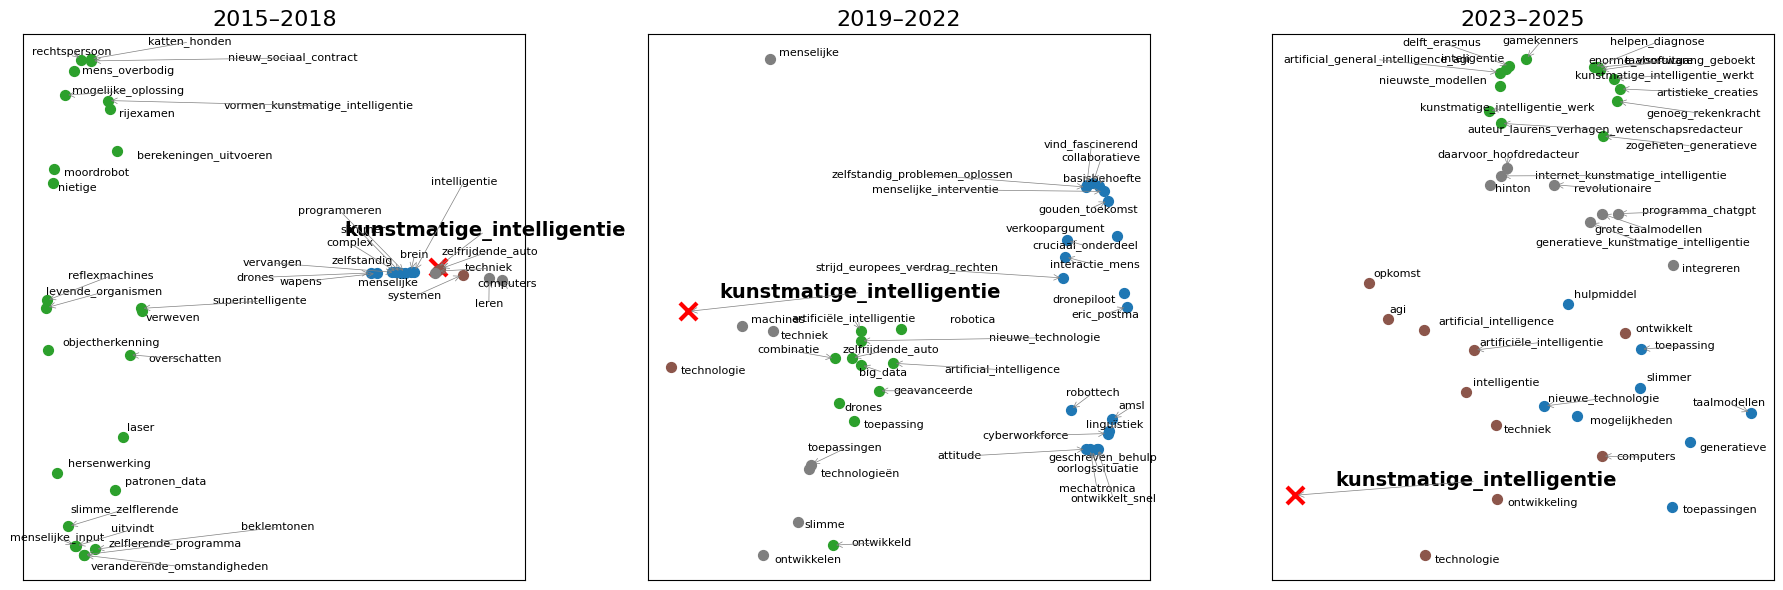

In [103]:
# -----------------------------
# 5) Train per period & plot
# -----------------------------
fig, axes = plt.subplots(1, len(periods), figsize=(6 * len(periods), 6), squeeze=False)

for ax, (start, end) in zip(axes[0], periods):
    docs_raw = docs_in_period(all_docs_tokens, years, start, end)
    docs = [apply_phrasing(d) for d in docs_raw]

    n_docs = len(docs)
    n_tokens = sum(len(d) for d in docs)
    freq_center = sum(d.count(center_word) for d in docs)

    print(f"\nPeriod {start}-{end}: docs={n_docs}, tokens={n_tokens}, '{center_word}' freq={freq_center}")

    if n_docs < 20 or n_tokens < 1000:
        ax.text(0.5, 0.5, f"Too few docs/tokens\n{start}–{end}\n"
                          f"docs={n_docs}, tokens={n_tokens}",
                ha="center", va="center", fontsize=12)
        ax.axis("off")
        continue

    model = Word2Vec(
        sentences=docs,
        vector_size=100,
        window=5,
        min_count=min_count_period,
        workers=4,
        sg=0,
        epochs=10,
    )

    if center_word not in model.wv.key_to_index:
        ax.text(0.5, 0.5,
                f"'{center_word}' not in vocab\n{start}–{end}\n"
                f"(freq≈{freq_center}, min_count={min_count_period})",
                ha="center", va="center", fontsize=12)
        ax.axis("off")
        continue

    neighbors = [w for w, _ in model.wv.most_similar(center_word, topn=topn) if len(w) > 2]
    words = [center_word] + neighbors
    embs = np.vstack([model.wv[w] for w in words])

    km_labels = KMeans(n_clusters=n_clusters, random_state=42).fit_predict(embs)
    perp = max(5, min(30, len(words) - 1))
    embs_2d = TSNE(n_components=2, perplexity=perp, early_exaggeration=12.0,
                   max_iter=1500, random_state=42).fit_transform(embs)

    ax.set_title(f"{start}–{end}", fontsize=16)
    texts = []
    for i, w in enumerate(words):
        x, y = embs_2d[i]
        if w == center_word:
            ax.scatter(x, y, c="red", marker="x", s=150, linewidths=3)
            t = ax.text(x, y, w, fontsize=14, fontweight="bold")
        else:
            col = plt.cm.tab10(km_labels[i] / n_clusters)
            ax.scatter(x, y, color=col, s=50)
            t = ax.text(x, y, w, fontsize=8)
        texts.append(t)

    adjust_text(texts, ax=ax, expand_points=(1.2, 1.2),
                arrowprops=dict(arrowstyle="->", color="gray", lw=0.5))
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout(); plt.show()


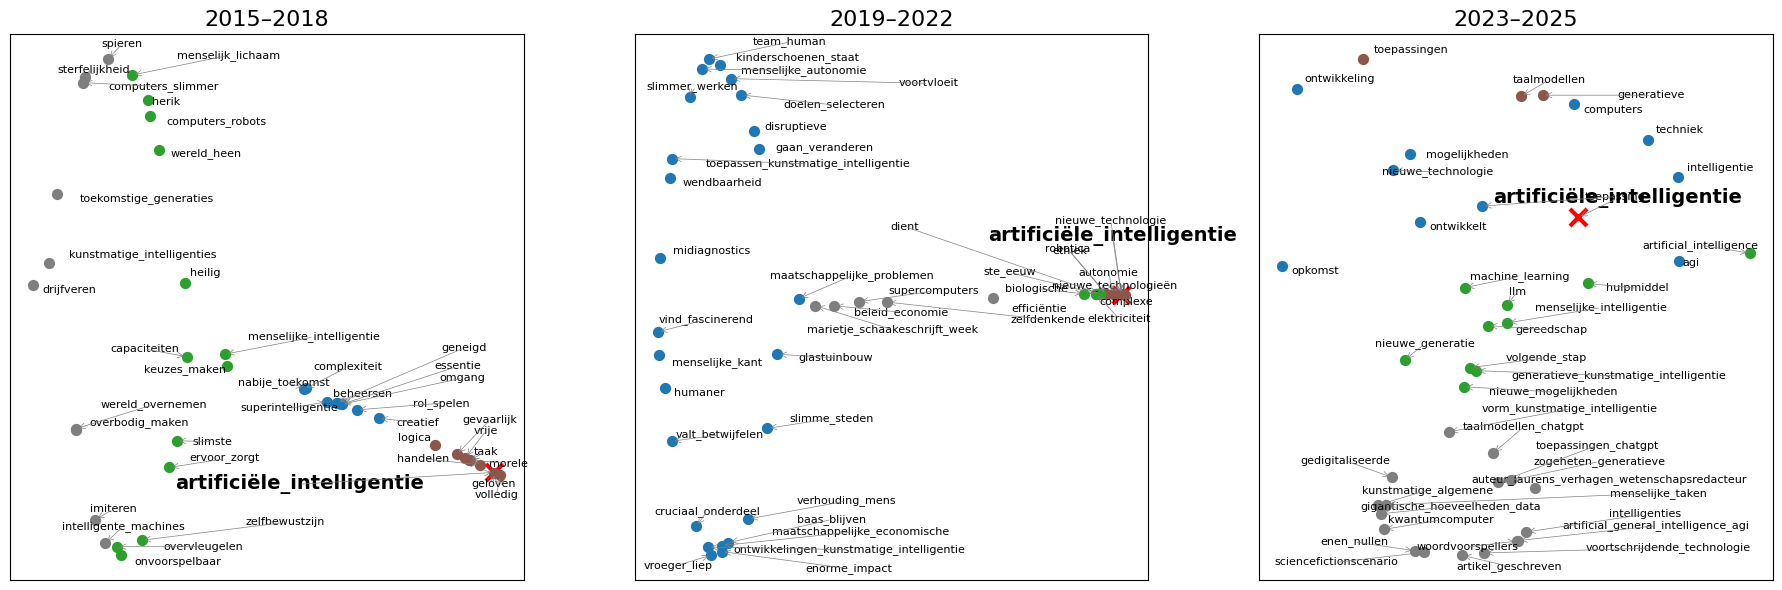

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from adjustText import adjust_text

center_word = "artificiële_intelligentie"
topn        = 40
n_clusters  = 4
periods = [
    (2015, 2018),
    (2019, 2022),
    (2023, 2025),
]
min_count = 2

years = df['year'].astype(int).tolist()

fig, axes = plt.subplots(1, len(periods), figsize=(6 * len(periods), 6), squeeze=False)

for ax, (start, end) in zip(axes[0], periods):
    docs_raw = docs_in_period(all_docs_tokens, years, start, end)
    docs = [apply_phrasing(d) for d in docs_raw]
    if len(docs) < 50:
        ax.text(0.5, 0.5, f"Too few docs\n{start}–{end}",
                ha="center", va="center", fontsize=14)
        ax.axis("off")
        continue

    model = Word2Vec(
        sentences=docs,
        vector_size=100,
        window=5,
        min_count=min_count,
        workers=4,
        sg=0,
        epochs=10
    )

    if center_word not in model.wv:
        ax.text(0.5, 0.5, f"'{center_word}' not in vocab\n{start}–{end}",
                ha="center", va="center", fontsize=14)
        ax.axis("off")
        continue

    neighbors = [w for w, _ in model.wv.most_similar(center_word, topn=topn) if len(w) > 2]
    words     = [center_word] + neighbors
    embs      = np.vstack([model.wv[w] for w in words])

    km_labels = KMeans(n_clusters=n_clusters, random_state=42).fit_predict(embs)

    perp    = min(30, len(words) - 1)
    embs_2d = TSNE(n_components=2, perplexity=perp, early_exaggeration=12.0,
                   max_iter=1500, random_state=42).fit_transform(embs)

    ax.set_title(f"{start}–{end}", fontsize=16)
    text_handles = []
    for i, w in enumerate(words):
        x, y = embs_2d[i]
        if w == center_word:
            ax.scatter(x, y, c='red', marker='x', s=150, linewidths=3)
            txt = ax.text(x, y, w, fontsize=14, fontweight='bold')
        else:
            col = plt.cm.tab10(km_labels[i] / n_clusters)
            ax.scatter(x, y, color=col, s=50)
            txt = ax.text(x, y, w, fontsize=8)
        text_handles.append(txt)

    adjust_text(
        text_handles, ax=ax,
        expand_points=(1.2, 1.2),
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.5)
    )
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

In [89]:
# import numpy as np
# import matplotlib.pyplot as plt
# from gensim.models import Word2Vec
# from sklearn.cluster import KMeans
# import umap
# from adjustText import adjust_text

# center_word = "artificiële_intelligentie"
# topn        = 25
# n_clusters  = 4
# periods     = [(2014,2016),(2017,2019),(2020,2023)]
# min_count   = 2

# years = df['year'].astype(int).tolist()

# fig, axes = plt.subplots(1, len(periods), figsize=(8*len(periods), 8), squeeze=False)

# for ax, (s,e) in zip(axes[0], periods):
#     docs_raw = docs_in_period(all_docs_tokens, years, s, e)
#     docs = [apply_phrasing(d) for d in docs_raw]
#     if len(docs) < 50:
#         ax.text(.5,.5, f"Too few docs\n{s}–{e}", ha="center", va="center", fontsize=16)
#         ax.axis('off')
#         continue

#     model = Word2Vec(docs, vector_size=100, window=5, min_count=min_count,
#                      workers=4, sg=0, epochs=10)

#     if center_word not in model.wv:
#         ax.text(.5,.5, f"'{center_word}' not in vocab\n{s}–{e}",
#                 ha="center", va="center", fontsize=16)
#         ax.axis('off')
#         continue

#     neighs = [w for w,_ in model.wv.most_similar(center_word, topn=topn) if len(w) > 2]
#     words  = [center_word] + neighs
#     embs   = np.vstack([model.wv[w] for w in words])

#     labels = KMeans(n_clusters=n_clusters, random_state=42).fit_predict(embs)

#     reducer = umap.UMAP(n_neighbors=15, min_dist=0.3, metric='cosine', random_state=42)
#     emb2d   = reducer.fit_transform(embs)

#     ax.set_title(f"{s}–{e}", fontsize=18)
#     texts = []
#     for i,w in enumerate(words):
#         x,y = emb2d[i]
#         if w == center_word:
#             ax.scatter(x, y, marker='X', s=200, color='red')
#             txt = ax.text(x, y, w, fontsize=14, fontweight='bold')
#         else:
#             ax.scatter(x, y, s=30, alpha=0.7,
#                        color=plt.cm.tab10(labels[i]/n_clusters))
#             txt = ax.text(x, y, w, fontsize=8)
#         texts.append(txt)

#     adjust_text(texts, ax=ax, expand_text=(1.2,1.2), arrowprops=None)
#     ax.set_xticks([]); ax.set_yticks([])

# plt.tight_layout()
# plt.show()

c:\Users\joly-\Github\HUMAN\.venv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\joly-\Github\HUMAN\.venv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\joly-\Github\HUMAN\.venv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


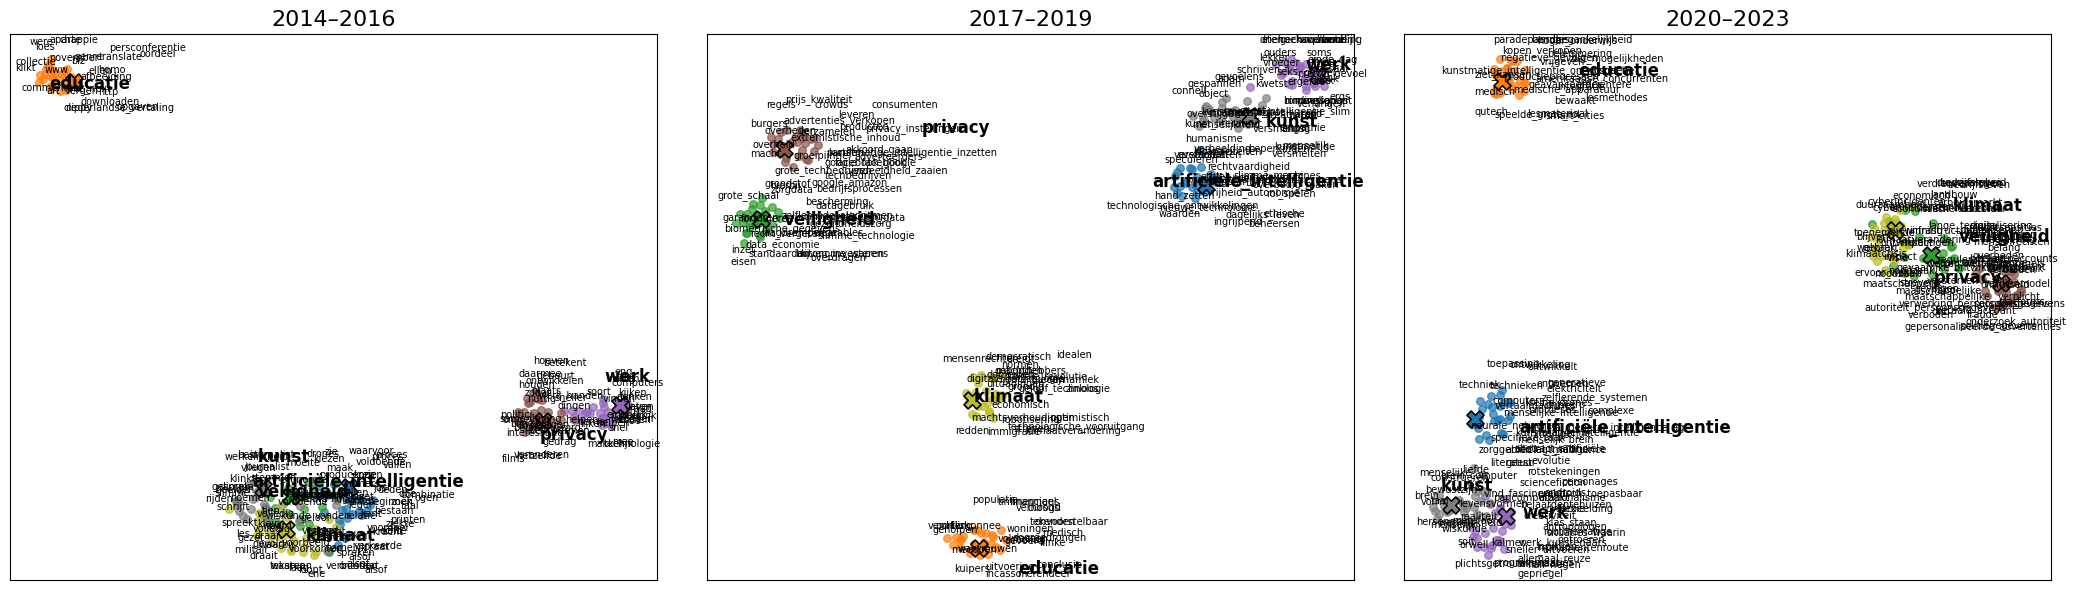

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.cluster import KMeans
import umap
from adjustText import adjust_text

center_words = ["artificiële_intelligentie", "veiligheid", "werk", "privacy"]
topn         = 25
n_clusters   = 4
periods      = [(2014,2016), (2017,2019), (2020,2023)]
min_count    = 2

years = df['year'].astype(int).tolist()

fig, axes = plt.subplots(1, len(periods), figsize=(7*len(periods), 6), squeeze=False)

for ax, (s, e) in zip(axes[0], periods):
    docs_raw = docs_in_period(all_docs_tokens, years, s, e)
    docs = [apply_phrasing(d) for d in docs_raw]
    ax.set_title(f"{s}–{e}", fontsize=16)

    if len(docs) < 50:
        ax.text(.5, .5, f"Too few docs\n{s}–{e}", ha="center", va="center", fontsize=14)
        ax.axis('off')
        continue

    model = Word2Vec(docs, vector_size=100, window=5, min_count=min_count,
                     workers=4, sg=0, epochs=10)

    neighbourhoods = {}
    for cw in center_words:
        if cw in model.wv:
            neighbourhoods[cw] = [w for w,_ in model.wv.most_similar(cw, topn=topn) if len(w) > 2]
        else:
            neighbourhoods[cw] = []

    words, labels = [], []
    for idx, cw in enumerate(center_words):
        words.append(cw); labels.append(idx)
        for w in neighbourhoods[cw]:
            words.append(w); labels.append(idx)

    embs = np.vstack([model.wv[w] for w in words])

    reducer = umap.UMAP(n_neighbors=15, min_dist=0.3, metric='cosine', random_state=42)
    emb2d = reducer.fit_transform(embs)

    texts = []
    for i, w in enumerate(words):
        x, y = emb2d[i]
        colour = plt.cm.tab10(labels[i] / len(center_words))
        if w in center_words:
            ax.scatter(x, y, marker='X', s=150, color=colour, edgecolor='k', linewidth=1.2, zorder=3)
            txt = ax.text(x, y, w, fontsize=12, fontweight='bold', zorder=4)
        else:
            ax.scatter(x, y, s=30, color=colour, alpha=0.7, zorder=2)
            txt = ax.text(x, y, w, fontsize=7, zorder=3)
        texts.append(txt)

    adjust_text(texts, ax=ax, expand_text=(1.1, 1.1), arrowprops=None)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

In [96]:
from collections import Counter                                                                                                                                                                                                                         
all_tokens = [tok for doc in all_docs_tokens for tok in doc]
print(Counter(all_tokens).most_common(50))

[('mensen', 22813), ('jaar', 22366), ('zegt', 17126), ('gaat', 17000), ('nieuwe', 16794), ('page', 16605), ('maken', 16017), ('gaan', 13766), ('intelligentie', 12673), ('zien', 11995), ('goed', 11954), ('grote', 11917), ('kunstmatige', 11613), ('bedrijf', 10761), ('google', 10140), ('bedrijven', 9509), ('staat', 9402), ('twee', 9384), ('wereld', 9383), ('tijd', 9353), ('komt', 9172), ('heel', 9128), ('facebook', 8930), ('nederland', 8807), ('amerikaanse', 8705), ('komen', 8561), ('end', 8536), ('date', 8532), ('document', 8464), ('load', 8334), ('technologie', 7578), ('data', 7557), ('laten', 7506), ('mee', 7330), ('willen', 7196), ('via', 7160), ('leven', 7029), ('the', 6938), ('maakt', 6912), ('procent', 6870), ('werk', 6822), ('jaren', 6660), ('media', 6595), ('echt', 6589), ('elkaar', 6560), ('euro', 6555), ('krijgen', 6390), ('onderzoek', 6385), ('vraag', 6299), ('nodig', 6065)]


c:\Users\joly-\Github\HUMAN\.venv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\joly-\Github\HUMAN\.venv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\joly-\Github\HUMAN\.venv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


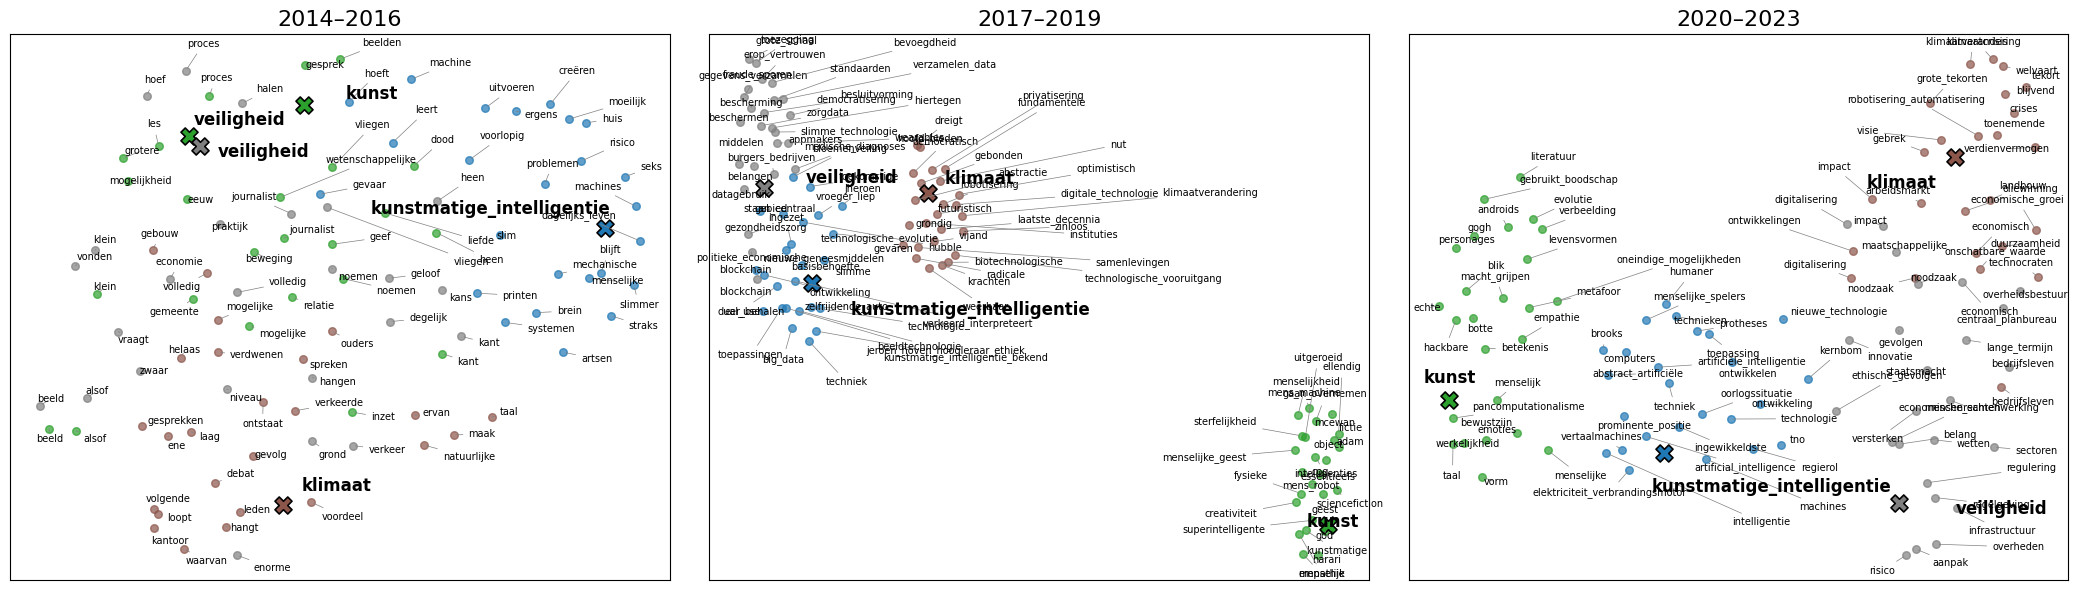

In [106]:
import numpy as np
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
import umap
from adjustText import adjust_text

def radial_offsets(emb2d, scale=0.05):
    centroid = emb2d.mean(axis=0)
    vecs = emb2d - centroid
    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    norms[norms == 0] = 1
    unit = vecs / norms
    return unit * scale

center_words = ["kunstmatige_intelligentie", "kunst", "klimaat", "veiligheid"]
topn         = 25
n_clusters   = 4
periods      = [(2014,2016), (2017,2019), (2020,2023)]
min_count    = 2

years = df['year'].astype(int).tolist()

fig, axes = plt.subplots(1, len(periods), figsize=(7*len(periods), 6), squeeze=False)

for ax, (s, e) in zip(axes[0], periods):
    docs_raw = docs_in_period(all_docs_tokens, years, s, e)
    docs = [apply_phrasing(d) for d in docs_raw]
    ax.set_title(f"{s}–{e}", fontsize=16)

    if len(docs) < 50:
        ax.text(.5, .5, f"Too few docs\n{s}–{e}", ha="center", va="center", fontsize=14)
        ax.axis('off')
        continue

    model = Word2Vec(docs, vector_size=100, window=5, min_count=min_count,
                     workers=4, sg=0, epochs=10)

    neighbourhoods = {}
    for cw in center_words:
        if cw in model.wv:
            neighbourhoods[cw] = [w for w,_ in model.wv.most_similar(cw, topn=topn) if len(w) > 2]
        else:
            neighbourhoods[cw] = []

    words, labels = [], []
    for idx, cw in enumerate(center_words):
        words.append(cw); labels.append(idx)
        for w in neighbourhoods[cw]:
            words.append(w); labels.append(idx)

    embs = np.vstack([model.wv[w] for w in words])

    reducer = umap.UMAP(n_neighbors=15, min_dist=0.3, metric='cosine', random_state=42)
    emb2d = reducer.fit_transform(embs)

    offsets = radial_offsets(emb2d, scale=0.08)

    texts = []
    for i, w in enumerate(words):
        x, y = emb2d[i]
        dx, dy = offsets[i]
        colour = plt.cm.tab10(labels[i] / len(center_words))

        if w in center_words:
            ax.scatter(x, y, marker='X', s=150, color=colour,
                       edgecolor='k', linewidth=1.2, zorder=3)
            txt = ax.text(x, y, w, fontsize=12, fontweight='bold', zorder=4)
        else:
            ax.scatter(x, y, s=30, color=colour, alpha=0.7, zorder=2)
            txt = ax.annotate(
                w, xy=(x, y), xytext=(x + dx, y + dy),
                textcoords='data', fontsize=7,
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
                zorder=3,
            )
        texts.append(txt)

    adjust_text(texts, ax=ax,
                expand_points=(1.4, 1.4), expand_text=(1.2, 1.2),
                force_points=(0.2, 0.5), force_text=(0.3, 0.7), lim=2000)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

c:\Users\joly-\Github\HUMAN\.venv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\joly-\Github\HUMAN\.venv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\joly-\Github\HUMAN\.venv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


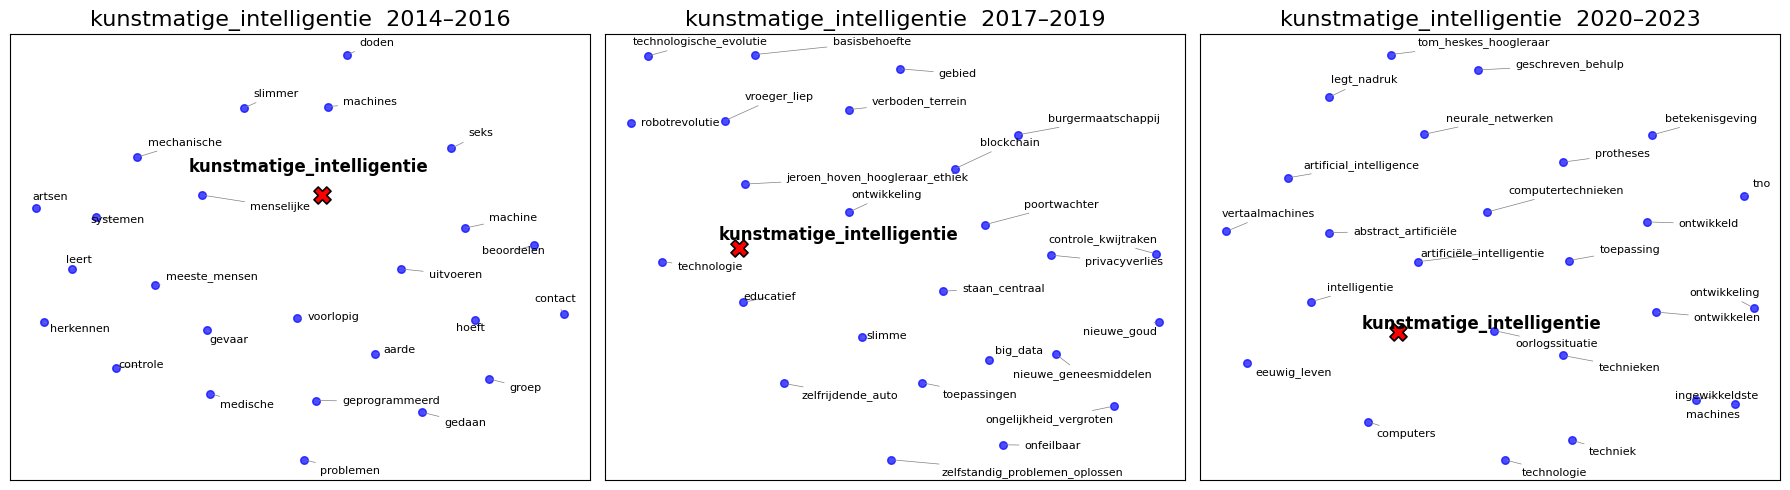

c:\Users\joly-\Github\HUMAN\.venv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\joly-\Github\HUMAN\.venv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\joly-\Github\HUMAN\.venv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


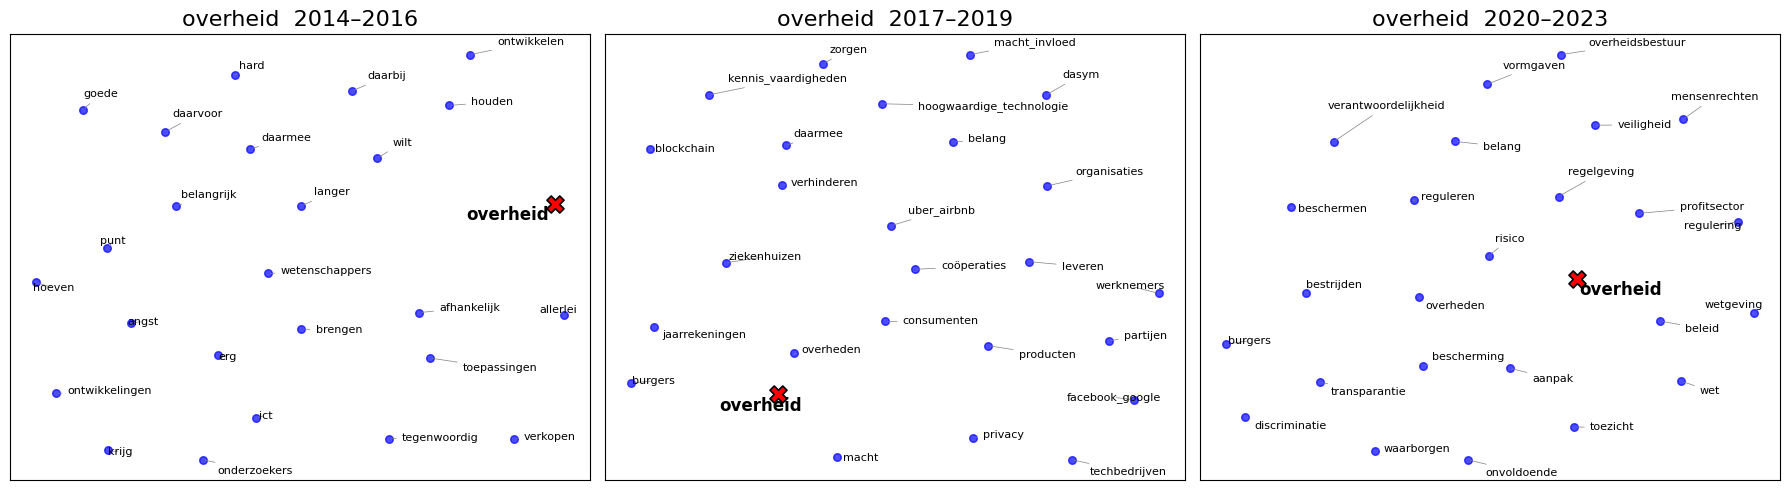

c:\Users\joly-\Github\HUMAN\.venv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\joly-\Github\HUMAN\.venv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\joly-\Github\HUMAN\.venv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


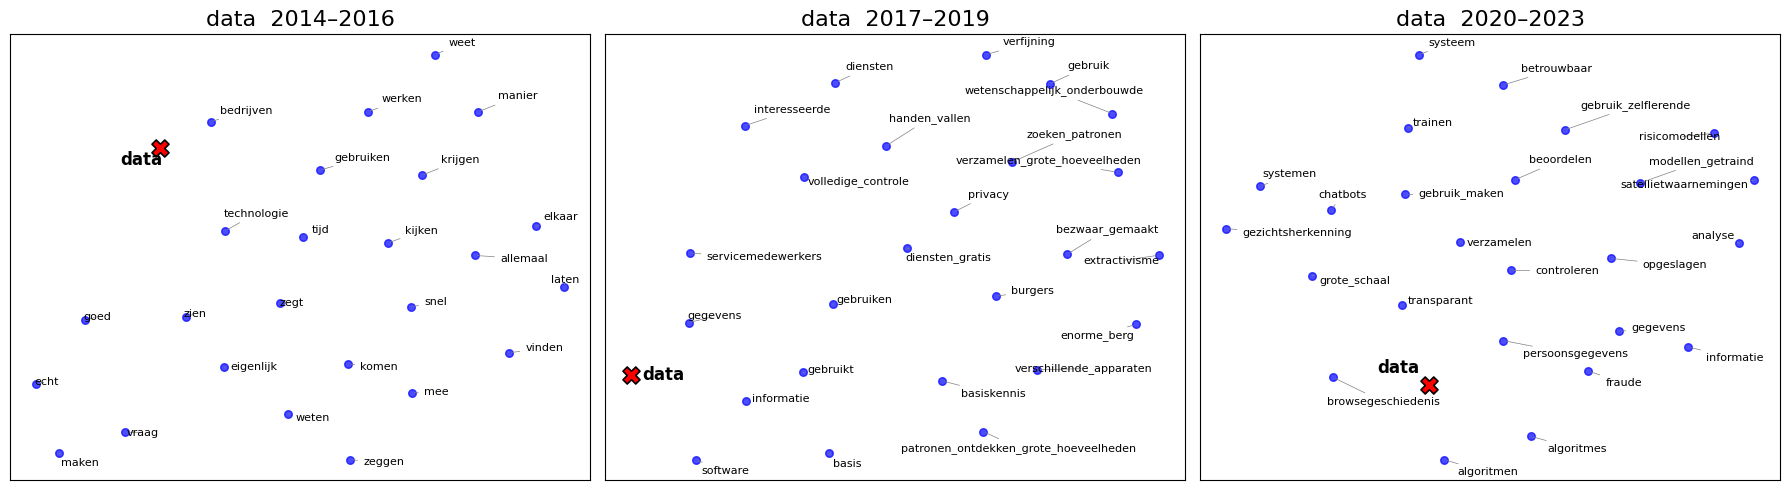

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
import umap
from adjustText import adjust_text

def radial_offsets(emb2d, scale=0.05):
    centroid = emb2d.mean(axis=0)
    vecs = emb2d - centroid
    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    norms[norms == 0] = 1
    unit = vecs / norms
    return unit * scale

center_words = ["kunstmatige_intelligentie", "overheid", "data"]
topn         = 25
n_clusters   = 4
periods      = [(2014,2016), (2017,2019), (2020,2023)]
min_count    = 2
years        = df['year'].astype(int).tolist()

for cw in center_words:
    fig, axes = plt.subplots(1, len(periods), figsize=(6*len(periods), 5), squeeze=False)

    for ax, (s, e) in zip(axes[0], periods):
        ax.set_title(f"{cw}  {s}–{e}", fontsize=16)
        docs_raw = docs_in_period(all_docs_tokens, years, s, e)
        docs = [apply_phrasing(d) for d in docs_raw]

        if len(docs) < 50:
            ax.text(.5, .5, f"Too few docs\n{s}–{e}",
                    ha="center", va="center", fontsize=14)
            ax.axis('off')
            continue

        model = Word2Vec(docs, vector_size=100, window=5, min_count=min_count,
                         workers=4, sg=0, epochs=10)

        if cw in model.wv:
            neighs = [w for w,_ in model.wv.most_similar(cw, topn=topn) if len(w) > 2]
        else:
            neighs = []

        words = [cw] + neighs
        embs  = np.vstack([model.wv[w] for w in words])

        reducer = umap.UMAP(n_neighbors=15, min_dist=0.3, metric='cosine', random_state=42)
        emb2d = reducer.fit_transform(embs)

        offsets = radial_offsets(emb2d, scale=0.08)
        texts = []

        for i, w in enumerate(words):
            x, y = emb2d[i]
            dx, dy = offsets[i]

            if i == 0:
                ax.scatter(x, y, marker='X', s=150, color='red',
                           edgecolor='k', linewidth=1.2, zorder=3)
                txt = ax.text(x, y, w, fontsize=12, fontweight='bold',
                              ha='center', va='center', zorder=4)
            else:
                ax.scatter(x, y, s=30, color='blue', alpha=0.7, zorder=2)
                txt = ax.annotate(
                    w, xy=(x, y), xytext=(x + dx, y + dy),
                    textcoords='data', fontsize=8,
                    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
                    zorder=3,
                )
            texts.append(txt)

        adjust_text(texts, ax=ax,
                    expand_points=(1.4, 1.4), expand_text=(1.2, 1.2),
                    force_points=(0.2, 0.5), force_text=(0.3, 0.7), lim=2000)
        ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout()
    plt.show()

In [99]:
  # train on the full corpus first
model_full = Word2Vec(sentences=[apply_phrasing(d) for d in all_docs_tokens],
                       vector_size=100, window=5, min_count=3, workers=4, epochs=10)
  # then explore
print(model_full.wv.most_similar("algoritme", topn=20))
print(model_full.wv.most_similar("overheid", topn=20))

[('algoritmen', 0.6980799436569214), ('algoritmes', 0.6837795376777649), ('systeem', 0.6465257406234741), ('mechanisme', 0.5815566182136536), ('fraudeur', 0.561806321144104), ('sollicitant', 0.5553737878799438), ('beoordeeld', 0.5498676300048828), ('vooroordelen', 0.5360215902328491), ('procent_gevallen', 0.5355255603790283), ('basis', 0.5325109958648682), ('profiel', 0.5287372469902039), ('methode', 0.5276594758033752), ('model', 0.5210544466972351), ('algoritme_ontwikkeld', 0.5204949378967285), ('hersenscans', 0.5175743699073792), ('discrimineert', 0.5162299871444702), ('algoritme_bepaalt', 0.515973687171936), ('bijstandsaanvragen', 0.5151347517967224), ('voorspellen', 0.5135599970817566), ('huidplekje', 0.5131845474243164)]
[('overheden', 0.7452608942985535), ('burgers', 0.7227766513824463), ('toezicht', 0.7221152782440186), ('wettelijke', 0.7033532857894897), ('nederlandse_overheid', 0.7011512517929077), ('ministerie', 0.6976051330566406), ('private_partijen', 0.6949558854103088), 

In [100]:
for start, end in periods:
    docs = [apply_phrasing(d) for d in docs_in_period(all_docs_tokens, years, start, end)]
    model = Word2Vec(sentences=docs, vector_size=100, window=5, min_count=2, workers=4, epochs=10)
    print(f"{start}-{end}: {'baan' in model.wv}")

2014-2016: True
2017-2019: True
2020-2023: True
